# Time series mini-project: AAPL and XLK (Python study)
Classical core in Python (exploration, ARIMA/SARIMA, VAR and cointegration, GARCH) and the advanced models (LSTM and GRU with walk-forward validation).
**Requirements** (install once, ideally in a virtual environment): `pip install yfinance pandas numpy matplotlib statsmodels scipy pmdarima arch tensorflow`
**How to run:** run all cells in order. The notebook can live in `notebooks/`: the first cell moves to the project root, where `data/` and `figures/` are. Prices are downloaded once and cached in `data/` (if `data/prices_R.csv` from the R study exists, it is used as a fallback). The LSTM/GRU cell takes about 7 minutes on a laptop CPU; set `QUICK` to `"1"` in the next cell for a 1-minute smoke test. Seeds are fixed (42).

In [1]:
# Run once on a new machine or kernel: set INSTALL = True. It installs into the Python that runs THIS notebook (the kernel),
# which fixes "ModuleNotFoundError". Afterwards set it back to False. (tensorflow is large: allow a few minutes.)
INSTALL = False
if INSTALL:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "yfinance", "pandas", "numpy", "matplotlib",
                           "statsmodels", "scipy", "pmdarima", "arch", "tensorflow"])
    print("Done. Restart the kernel (Kernel > Restart), then run the notebook from the top.")

In [2]:
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")                      # scripts use paths relative to the project root
os.environ.setdefault("QUICK", "0")     # "1" = quick smoke test of the neural networks
from IPython.display import Image, display
import glob
def show(*patterns):                    # display the figures written by the previous cell
    for p in patterns:
        for f in sorted(glob.glob(os.path.join("figures", p))): display(Image(f))
print(sys.version)
print('Kernel Python:', sys.executable)   # must be the interpreter where the packages are installed

3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
Kernel Python: c:\Users\User\anaconda3\python.exe


## 1-2. Data preparation and exploratory analysis
Source: `python/01_data_eda.py` (the same file is in the repository; every block is commented with its purpose).

In [3]:
"""
PART 1 (Python) - Data import, preparation and exploratory analysis
Pair: AAPL (stock) + XLK (its sector ETF). Daily, 2019-01-01 -> 2026-09-30.
Install: pip install yfinance pandas numpy matplotlib statsmodels scipy
Run (from the PROJECT ROOT): python python/01_data_eda.py
"""
import os, random, warnings
import numpy as np, pandas as pd
import matplotlib
matplotlib.use("Agg")  # no display needed: figures are saved to files
import matplotlib.pyplot as plt
import statsmodels
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL

warnings.filterwarnings("ignore", category=UserWarning)

# Fixed seed + fixed date window: same results on every run (reproducibility criterion)
SEED = 42; random.seed(SEED); np.random.seed(SEED)
TICKERS, START, END = ["AAPL", "XLK"], "2019-01-01", "2026-09-30"
os.makedirs("data", exist_ok=True); os.makedirs("figures", exist_ok=True)
print("statsmodels", statsmodels.__version__, "| pandas", pd.__version__, "| numpy", np.__version__)

# ---------------------------------------------------------------- 1. IMPORT
# Cache to CSV so the notebook re-runs offline and the data cannot silently change.
CSV = "data/prices.csv"
if os.path.exists(CSV):
    df = pd.read_csv(CSV, index_col=0, parse_dates=True)
elif os.path.exists("data/prices_R.csv"):
    # Fallback: reuse the R price cache (adjusted close only), so both languages use IDENTICAL data and no download is needed
    # (also works when Yahoo Finance is slow, blocked or offline). Only the adjusted close is used below.
    df = pd.read_csv("data/prices_R.csv", index_col=0, parse_dates=True)[["AAPL", "XLK"]].dropna()
    df.columns = ["AdjClose_AAPL", "AdjClose_XLK"]; df.index.name = "Date"
else:
    import yfinance as yf                      # imported only when a download is really needed
    parts = []
    for t in TICKERS:
        # auto_adjust=False keeps BOTH Close and Adj Close (dividend/split adjusted by Yahoo)
        d = yf.download(t, start=START, end=END, auto_adjust=False, progress=False)
        d.columns = [c[0] if isinstance(c, tuple) else c for c in d.columns]  # flatten MultiIndex
        d.columns = [f"{c.replace(' ', '')}_{t}" for c in d.columns]
        parts.append(d)
    df = pd.concat(parts, axis=1).dropna()  # inner alignment: same trading days for both assets
    df.index = pd.DatetimeIndex(df.index, name="Date")
    df.to_csv(CSV)
print(df.shape, df.index.min().date(), "->", df.index.max().date())

# Frequency note: trading days are NOT a regular calendar (weekends + holidays missing).
# We keep the real trading-day DatetimeIndex rather than forward-filling holidays,
# because filling would create fake zero returns and bias volatility downward.

# ------------------------------------------------- 2. DERIVED INDICATORS
for t in TICKERS:
    px = df[f"AdjClose_{t}"]
    df[f"lp_{t}"] = np.log(px)                                   # log price: stabilises variance, additive returns
    df[f"r_{t}"] = df[f"lp_{t}"].diff()                          # log return: the stationary object used for GARCH
    df[f"ma20_{t}"] = px.rolling(20).mean()                      # 20-day moving average (trend indicator)
    df[f"rv20_{t}"] = df[f"r_{t}"].rolling(20).std() * np.sqrt(252)  # annualised realised volatility
df = df.dropna(subset=[f"r_{t}" for t in TICKERS])

# --------------------------------------------- 3. CHRONOLOGICAL 90/10 SPLIT
n = len(df); cut = int(0.9 * n)
train, test = df.iloc[:cut], df.iloc[cut:]
print(f"Train: {train.index[0].date()} -> {train.index[-1].date()} ({len(train)} obs)")
print(f"Test : {test.index[0].date()} -> {test.index[-1].date()} ({len(test)} obs)")
# ALL exploration/identification below uses TRAIN ONLY: looking at the test set would leak information.
tr = train
MAIN = "AAPL"

# -------------------------------------------------- 4. EXPLORATORY PLOTS
fig, ax = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
for t in TICKERS:  # rebased to 100 so two different price scales are comparable
    ax[0].plot(tr.index, 100 * tr[f"AdjClose_{t}"] / tr[f"AdjClose_{t}"].iloc[0], label=t)
ax[0].plot(tr.index, 100 * tr[f"ma20_{MAIN}"] / tr[f"AdjClose_{MAIN}"].iloc[0], "k--", lw=.8, label=f"MA20 {MAIN}")
ax[0].set_title("Adjusted close (base 100)"); ax[0].legend()
for t in TICKERS: ax[1].plot(tr.index, tr[f"r_{t}"], lw=.6, label=t)
ax[1].set_title("Log returns"); ax[1].legend()
for t in TICKERS: ax[2].plot(tr.index, tr[f"rv20_{t}"], label=t)
ax[2].set_title("20-day realised volatility (annualised)"); ax[2].legend()
plt.tight_layout(); plt.savefig("figures/01_overview.png", dpi=130); plt.close()
print("Correlation of returns (train):", round(tr["r_AAPL"].corr(tr["r_XLK"]), 3))

# ------------------------------------------------ 5. ACF / PACF
# Raw log price (expect slowly decaying ACF = unit root) vs first difference (expect ~ white noise).
fig, ax = plt.subplots(2, 2, figsize=(12, 7))
x_lvl, x_ret = tr[f"lp_{MAIN}"], tr[f"r_{MAIN}"]
plot_acf(x_lvl, lags=40, ax=ax[0, 0], title="ACF log price");  plot_pacf(x_lvl, lags=40, ax=ax[0, 1], title="PACF log price", method="ywm")
plot_acf(x_ret, lags=40, ax=ax[1, 0], title="ACF log return"); plot_pacf(x_ret, lags=40, ax=ax[1, 1], title="PACF log return", method="ywm")
plt.tight_layout(); plt.savefig("figures/02_acf_pacf.png", dpi=130); plt.close()

# -------------------------------------------------- 6. STL DECOMPOSITION
# period=252 ~ one trading year. STL (not classical) is robust to outliers such as March 2020.
stl = STL(x_lvl.reset_index(drop=True), period=252, robust=True).fit()
fig = stl.plot(); fig.set_size_inches(11, 7); plt.tight_layout()
plt.savefig("figures/03_stl.png", dpi=130); plt.close()
print("STL: share of variance of detrended series explained by seasonal component =",
      round(1 - np.var(stl.resid) / np.var(stl.resid + stl.seasonal), 3))

# ----------------------------------------------------- 7. OUTLIERS
q1, q3 = x_ret.quantile([.25, .75]); iqr = q3 - q1
mask = (x_ret < q1 - 3 * iqr) | (x_ret > q3 + 3 * iqr)  # 3*IQR = "extreme" fence (1.5 would flag ~8% of fat-tailed returns)
print(f"\nExtreme returns (3*IQR rule): {mask.sum()} of {len(x_ret)}")
print(x_ret[mask].sort_values(key=abs, ascending=False).head(10).round(4))
# Treatment decision (to justify in the report): KEEP. These are genuine market events (e.g. Covid crash
# March 2020), not data errors; removing them would erase exactly the volatility GARCH must model.
# Check that none is a data glitch (e.g. an unadjusted split) before keeping.

# ------------------------------------- 8. DESCRIPTIVE STATS (reused for LLM section 5)
desc = pd.DataFrame({t: {
    "mean": tr[f"r_{t}"].mean(), "variance": tr[f"r_{t}"].var(),
    "skewness": stats.skew(tr[f"r_{t}"]), "excess_kurtosis": stats.kurtosis(tr[f"r_{t}"]),
    "JarqueBera_p": stats.jarque_bera(tr[f"r_{t}"])[1]} for t in TICKERS})
print("\nDescriptive statistics of log returns (train):\n", desc.round(6))
desc.to_csv("data/descriptive_stats.csv")

# ---------------------------------------- 9. STATIONARITY: ADF + KPSS
def stationarity(x, name, reg="c"):
    adf_p = adfuller(x.dropna(), regression=reg, autolag="AIC")[1]   # H0: unit root (non-stationary)
    kpss_p = kpss(x.dropna(), regression=reg, nlags="auto")[1]       # H0: stationary (opposite!)
    if adf_p < .05 and kpss_p >= .05: verdict = "STATIONARY (both agree)"
    elif adf_p >= .05 and kpss_p < .05: verdict = "NON-STATIONARY (both agree)"
    else: verdict = "INCONCLUSIVE / conflicting -> inspect, try differencing or a trend term"
    print(f"{name:<14} ADF p={adf_p:.4f} | KPSS p={kpss_p:.4f} (p reported is capped at 0.01-0.10) -> {verdict}")
print("\nStationarity tests (train):")
for t in TICKERS:
    stationarity(tr[f"lp_{t}"], f"log price {t}", reg="ct")  # 'ct' = constant + trend, plausible for a drifting price
    stationarity(tr[f"r_{t}"], f"log return {t}")
# Expected: log price I(1) -> d = 1; log return stationary -> d = 0 on returns.
# Write the conclusion in the report: "required order of differencing d = 1 on log prices".

df.to_csv("data/prepared.csv"); print("\nSaved data/prepared.csv, figures/*.png")


statsmodels 0.15.0 | pandas 2.2.3 | numpy 2.1.3
(1946, 12) 2019-01-02 -> 2026-09-29
Train: 2019-01-03 -> 2025-12-17 (1750 obs)
Test : 2025-12-18 -> 2026-09-29 (195 obs)
Correlation of returns (train): 0.827
STL: share of variance of detrended series explained by seasonal component = 0.141

Extreme returns (3*IQR rule): 19 of 1750
Date
2025-04-09    0.1426
2020-03-16   -0.1377
2020-03-13    0.1132
2019-01-03   -0.1049
2020-03-12   -0.1040
2020-07-31    0.0996
2025-04-03   -0.0970
2020-03-24    0.0956
2020-03-02    0.0890
2022-11-10    0.0852
Name: r_AAPL, dtype: float64

Descriptive statistics of log returns (train):
                      AAPL       XLK
mean             0.001131  0.000895
variance         0.000384  0.000284
skewness        -0.083262 -0.288791
excess_kurtosis  6.591950  8.893245
JarqueBera_p     0.000000  0.000000

Stationarity tests (train):
log price AAPL ADF p=0.2810 | KPSS p=0.0100 (p reported is capped at 0.01-0.10) -> NON-STATIONARY (both agree)
log return AAPL ADF

C:\Users\User\AppData\Local\Temp\ipykernel_1176\1538132572.py:120: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_p = adfuller(x.dropna(), regression=reg, autolag="AIC")[1]   # H0: unit root (non-stationary)
C:\Users\User\AppData\Local\Temp\ipykernel_1176\1538132572.py:121: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a KPSSResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  kpss_p = kp

log return XLK ADF p=0.0000 | KPSS p=0.1000 (p reported is capped at 0.01-0.10) -> STATIONARY (both agree)

Saved data/prepared.csv, figures/*.png


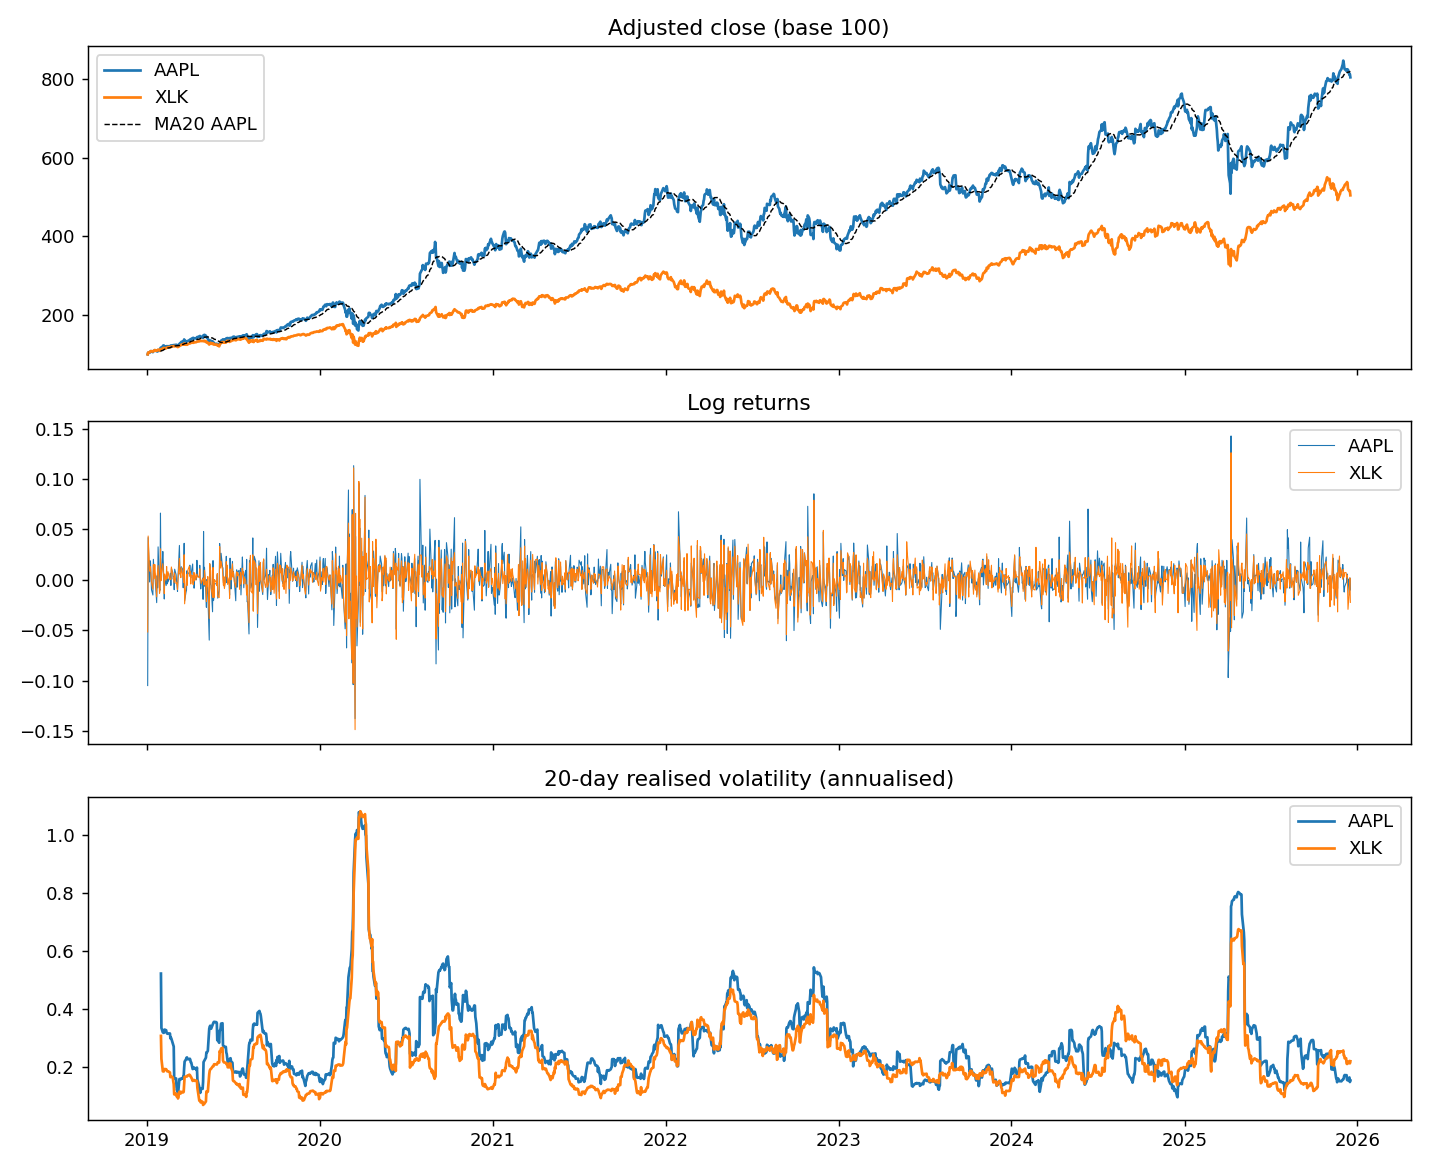

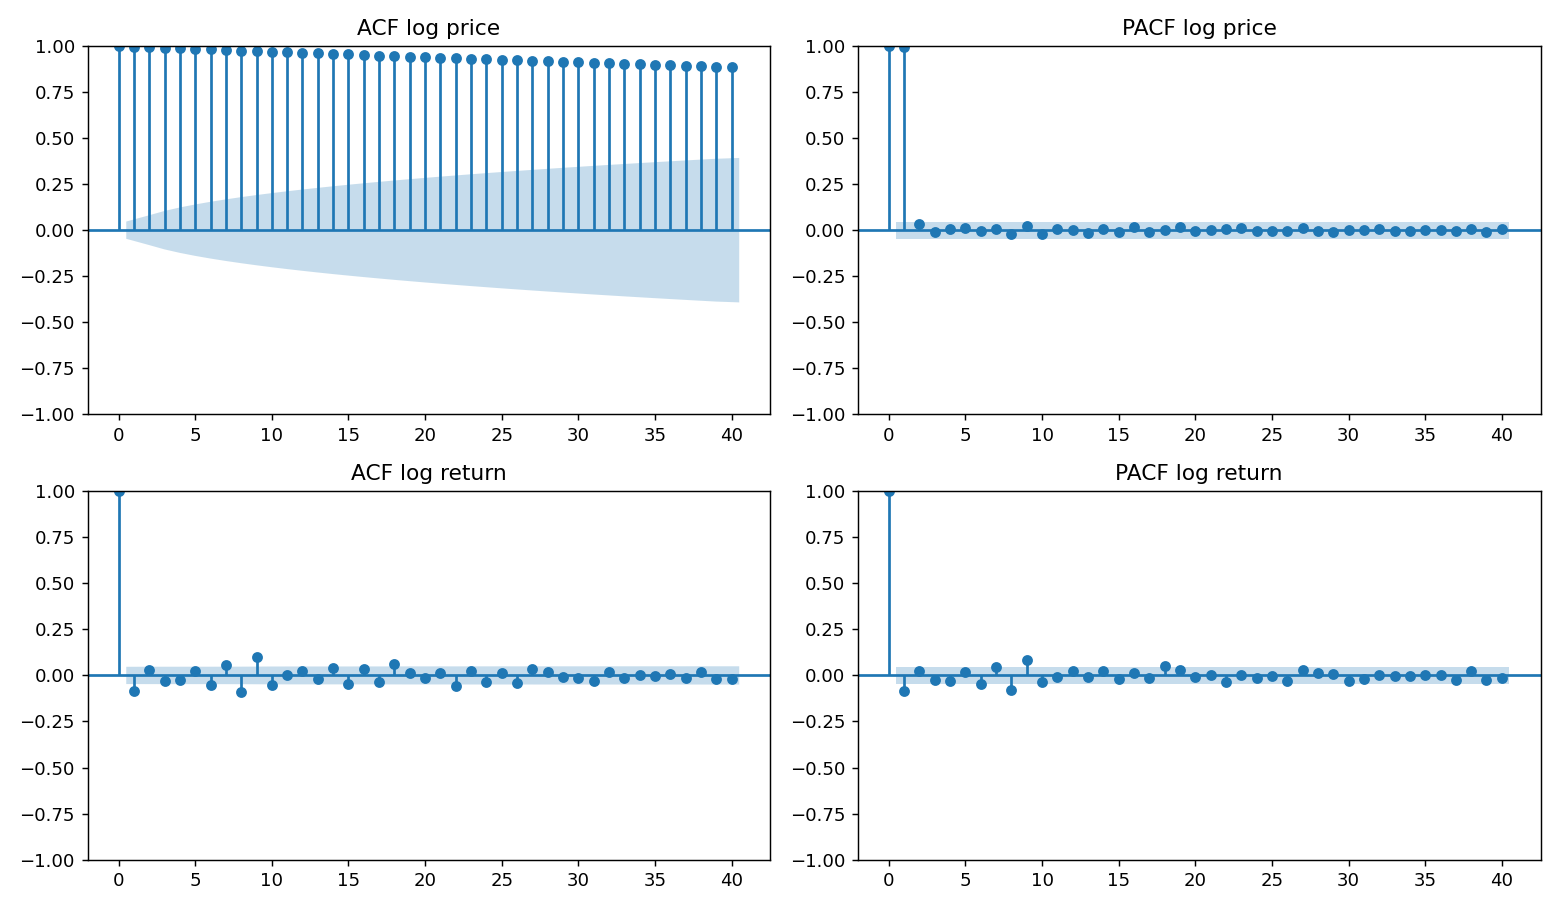

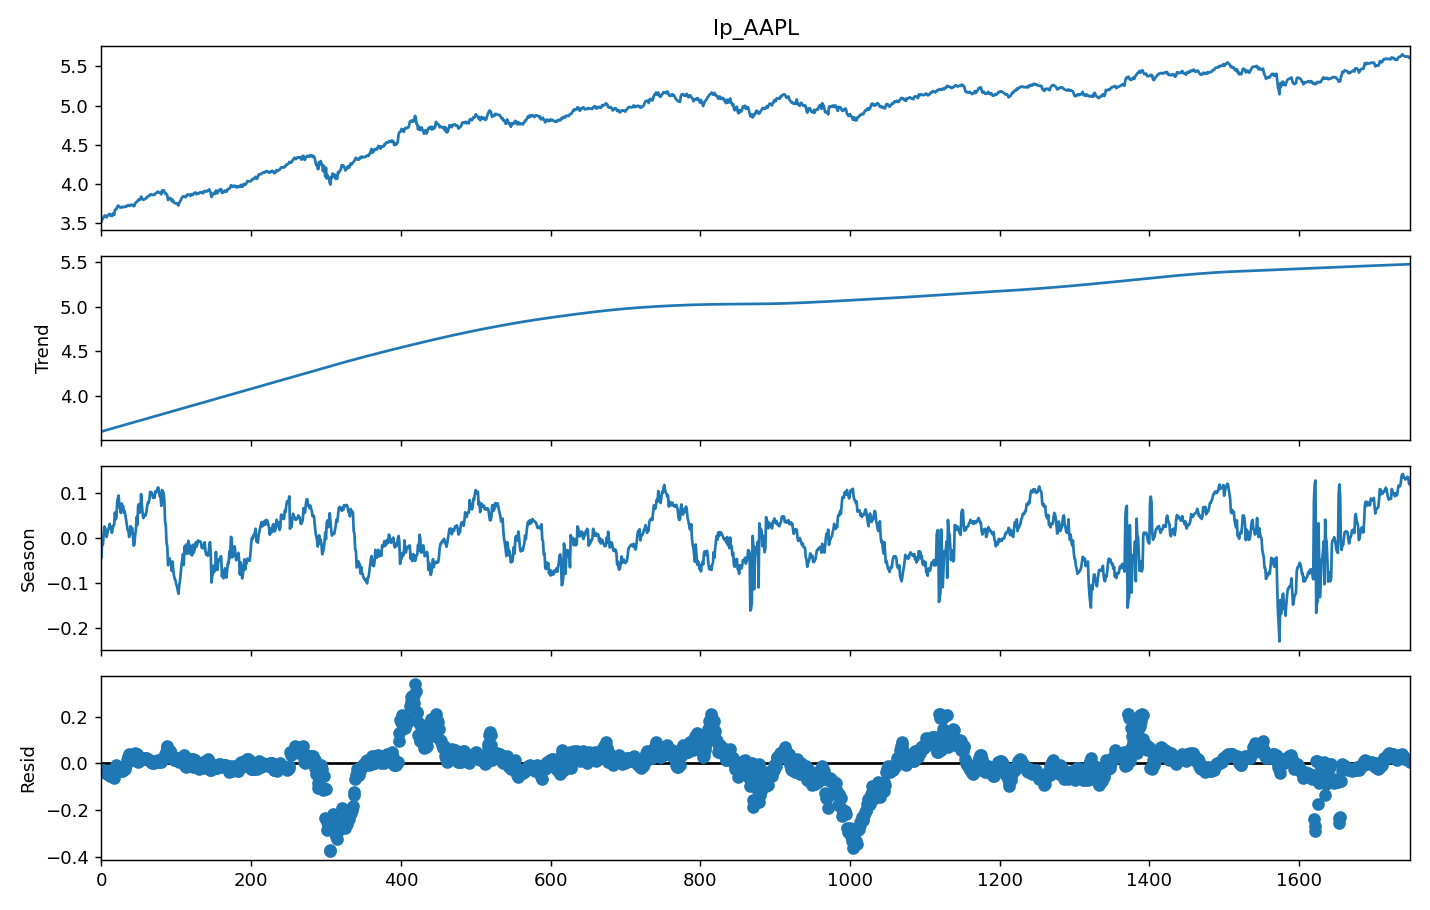

In [4]:
show('0[123]_*.png')

## 3.1 ARIMA / SARIMA
Source: `python/02_arima.py` (the same file is in the repository; every block is commented with its purpose).

In [5]:
"""
PART 2 (Python) - ARIMA / SARIMA identification, residual diagnostics, h=10 forecast
Run AFTER python/01_data_eda.py (or the R version: it falls back to data/prices_R.csv).
Install: pip install pmdarima statsmodels pandas numpy scipy matplotlib
"""
import os, random, warnings, itertools
import numpy as np, pandas as pd
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf
import pmdarima as pm

warnings.filterwarnings("ignore")
SEED = 42; random.seed(SEED); np.random.seed(SEED)   # reproducibility
os.makedirs("figures", exist_ok=True); os.makedirs("data", exist_ok=True)
H = 10                                               # forecast horizon (brief: h = 5..10)

# ---- 1. LOAD + SAME 90/10 SPLIT AS PART 1 (identical n and cut, so train/test never differ between scripts)
if os.path.exists("data/prices.csv"):
    px = pd.read_csv("data/prices.csv", index_col=0, parse_dates=True)["AdjClose_AAPL"]
else:
    px = pd.read_csv("data/prices_R.csv", index_col=0, parse_dates=True)["AAPL"]
lp = np.log(px).iloc[1:]                              # drop first obs: aligned with the return series of Part 1
n = len(lp); cut = int(0.9 * n)
train, test = lp.iloc[:cut].values, lp.iloc[cut:].values   # plain arrays: avoids irregular-frequency warnings
print(f"n={n} train={cut} test={n-cut}")

# ---- 2. MANUAL IDENTIFICATION from ACF/PACF of the differenced series (d=1 from ADF/KPSS in Part 1)
r = np.diff(train)
bound = 1.96 / np.sqrt(len(r))                        # 95% white-noise band
a, pa = acf(r, nlags=30)[1:], pacf(r, nlags=30)[1:]
print("\nSignificant ACF lags :", [i+1 for i, v in enumerate(a) if abs(v) > bound])
print("Significant PACF lags:", [i+1 for i, v in enumerate(pa) if abs(v) > bound])
print("(~5% of 30 lags exceed the band by chance alone: isolated lags are not evidence of structure)")
print(acorr_ljungbox(r, lags=[10, 20]).round(4))     # H0: returns are white noise

# ---- 3. SEARCH: (a) information-criterion grid, (b) pmdarima auto_arima -> compare both approaches
rows = []
for p, q in itertools.product(range(4), range(4)):
    try:
        f = ARIMA(train, order=(p, 1, q), trend="t").fit()   # trend='t' = drift on the differenced series
        rows.append((p, 1, q, f.aic, f.bic))
    except Exception: pass
grid = pd.DataFrame(rows, columns=["p", "d", "q", "AIC", "BIC"]).sort_values("BIC")
print("\nTop 5 by BIC (BIC penalises complexity more: favours parsimony):\n", grid.head(5).round(2).to_string(index=False))
bp, bq = int(grid.iloc[0].p), int(grid.iloc[0].q)

auto = pm.auto_arima(train, d=1, seasonal=False, information_criterion="bic",
                     stepwise=False, max_p=5, max_q=5, with_intercept=True, suppress_warnings=True)
print("\nauto_arima (non-seasonal):", auto.order, "| BIC =", round(auto.bic(), 2))

# SARIMA check: weekly cycle s=5 is the only plausible seasonality in daily trading data
sauto = pm.auto_arima(train, d=1, seasonal=True, m=5, D=0, information_criterion="bic",
                      stepwise=True, suppress_warnings=True)
print("auto_arima (seasonal m=5):", sauto.order, sauto.seasonal_order, "| BIC =", round(sauto.bic(), 2))
print("-> SARIMA only justified if its BIC is clearly lower than the non-seasonal model.")

# ---- 4. FINAL MODEL + FULL RESIDUAL DIAGNOSTICS
def fit_and_diagnose(order, name):
    fit = ARIMA(train, order=order, trend="t").fit()
    res = fit.resid[1:]                                # first residual is an initialisation artefact for d=1
    k = order[0] + order[2]
    lb = acorr_ljungbox(res, lags=[10, 20], model_df=k)     # H0: no residual autocorrelation
    jb = stats.jarque_bera(res); sh = stats.shapiro(res)    # H0: normal (will be rejected: fat tails)
    a5, a10 = het_arch(res, nlags=5), het_arch(res, nlags=10)  # H0: no ARCH effect (constant variance)
    print(f"\n=== Diagnostics {name} {order} ===")
    print("Ljung-Box p (lag10, lag20):", lb["lb_pvalue"].round(4).tolist())
    print(f"Jarque-Bera p={jb.pvalue:.4g} | Shapiro p={sh.pvalue:.4g} | excess kurt={stats.kurtosis(res):.2f}")
    print(f"ARCH-LM p (5 lags)={a5[1]:.4g} | (10 lags)={a10[1]:.4g}")
    fig, ax = plt.subplots(2, 2, figsize=(11, 7))
    ax[0, 0].plot(res, lw=.5); ax[0, 0].set_title("Residuals")
    plot_acf(res, lags=30, ax=ax[0, 1], title="ACF residuals")
    plot_acf(res**2, lags=30, ax=ax[1, 0], title="ACF squared residuals (ARCH check)")
    stats.probplot(res, plot=ax[1, 1]); ax[1, 1].set_title("QQ-plot")
    plt.tight_layout(); plt.savefig(f"figures/04_diag_{name}.png", dpi=130); plt.close()
    return fit
fit_grid = fit_and_diagnose((bp, 1, bq), "grid_BIC")
fit_auto = fit_and_diagnose(tuple(auto.order), "auto")
FIT = fit_grid                                        # choose one for forecasting; justify in report

# ---- 5. h=10 FORECAST vs RANDOM-WALK-WITH-DRIFT BASELINE (an ARIMA that cannot beat it adds nothing)
print(FIT.summary())   # coefficients, needed in the report
fc = FIT.get_forecast(H)
mu, ci = np.asarray(fc.predicted_mean), np.asarray(fc.conf_int(alpha=0.05))
drift = r.mean(); rw = train[-1] + drift * np.arange(1, H + 1)
actual = test[:H]
def metrics(y, yhat):                                  # computed on PRICE scale (exp of log price), the interpretable one
    y, yhat = np.exp(y), np.exp(yhat); e = y - yhat
    return dict(MSE=np.mean(e**2), RMSE=np.sqrt(np.mean(e**2)), MAE=np.mean(np.abs(e)), MAPE=100*np.mean(np.abs(e/y)))
tab = pd.DataFrame({f"ARIMA{(bp,1,bq)}": metrics(actual, mu), "RW+drift": metrics(actual, rw)}).T
print(f"\nForecast accuracy, h={H}, price scale:\n", tab.round(4))
cover = np.mean((actual >= ci[:, 0]) & (actual <= ci[:, 1]))
print(f"95% interval coverage on these {H} points: {cover:.0%}")
print("Caution: 10 points = very noisy comparison. Section 6 will use a rolling-origin evaluation + Diebold-Mariano.")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(-30, 0), np.exp(train[-30:]), label="train"); ax.plot(range(H), np.exp(actual), "k", label="actual")
ax.plot(range(H), np.exp(mu), "r", label="ARIMA"); ax.plot(range(H), np.exp(rw), "g--", label="RW+drift")
ax.fill_between(range(H), np.exp(ci[:, 0]), np.exp(ci[:, 1]), color="r", alpha=.15); ax.legend()
plt.tight_layout(); plt.savefig("figures/05_arima_forecast.png", dpi=130); plt.close()
pd.DataFrame({"actual_lp": actual, "arima_lp": mu, "lo": ci[:, 0], "hi": ci[:, 1], "rw_lp": rw}).to_csv("data/forecast_arima.csv", index=False)
tab.to_csv("data/metrics_arima.csv")


n=1945 train=1750 test=195

Significant ACF lags : [1, 6, 7, 8, 9, 10, 18, 22]
Significant PACF lags: [1, 6, 8, 9, 18]
(~5% of 30 lags exceed the band by chance alone: isolated lags are not evidence of structure)
    lb_stat  lb_pvalue
10  64.0221        0.0
20  87.5908        0.0

Top 5 by BIC (BIC penalises complexity more: favours parsimony):
  p  d  q      AIC      BIC
 1  1  0 -8826.38 -8809.98
 0  1  1 -8825.84 -8809.44
 0  1  0 -8817.50 -8806.56
 2  1  0 -8825.51 -8803.64
 1  1  1 -8825.50 -8803.63

auto_arima (non-seasonal): (1, 1, 0) | BIC = -8809.98
auto_arima (seasonal m=5): (1, 1, 0) (0, 0, 0, 5) | BIC = -8809.98
-> SARIMA only justified if its BIC is clearly lower than the non-seasonal model.

=== Diagnostics grid_BIC (1, 1, 0) ===
Ljung-Box p (lag10, lag20): [0.0, 0.0]
Jarque-Bera p=0 | Shapiro p=1.393e-26 | excess kurt=5.87
ARCH-LM p (5 lags)=1.699e-51 | (10 lags)=9.162e-52

=== Diagnostics auto (1, 1, 0) ===
Ljung-Box p (lag10, lag20): [0.0, 0.0]
Jarque-Bera p=0 | Shapi

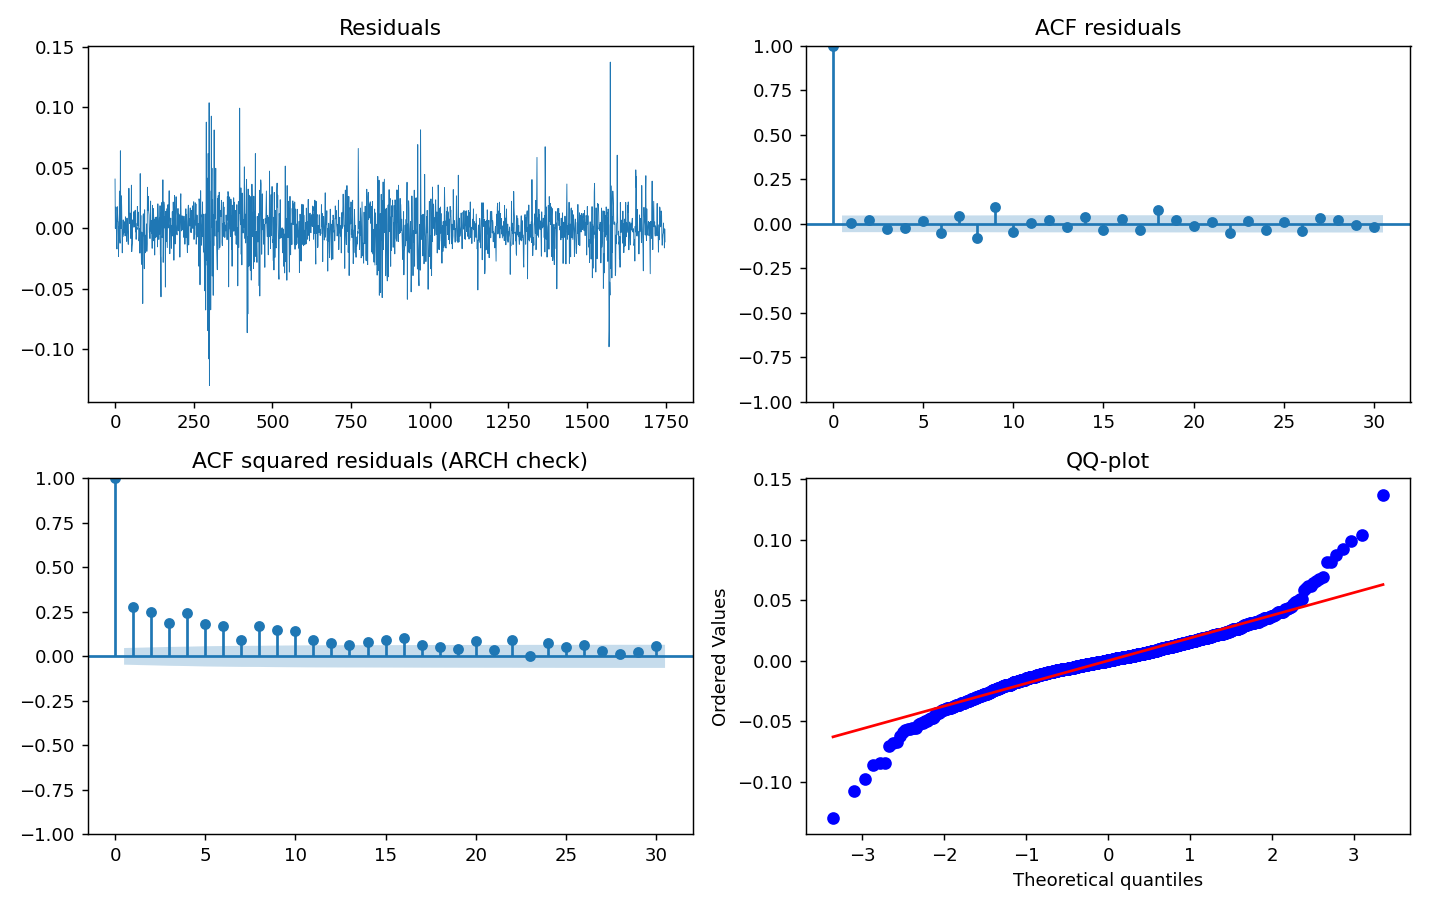

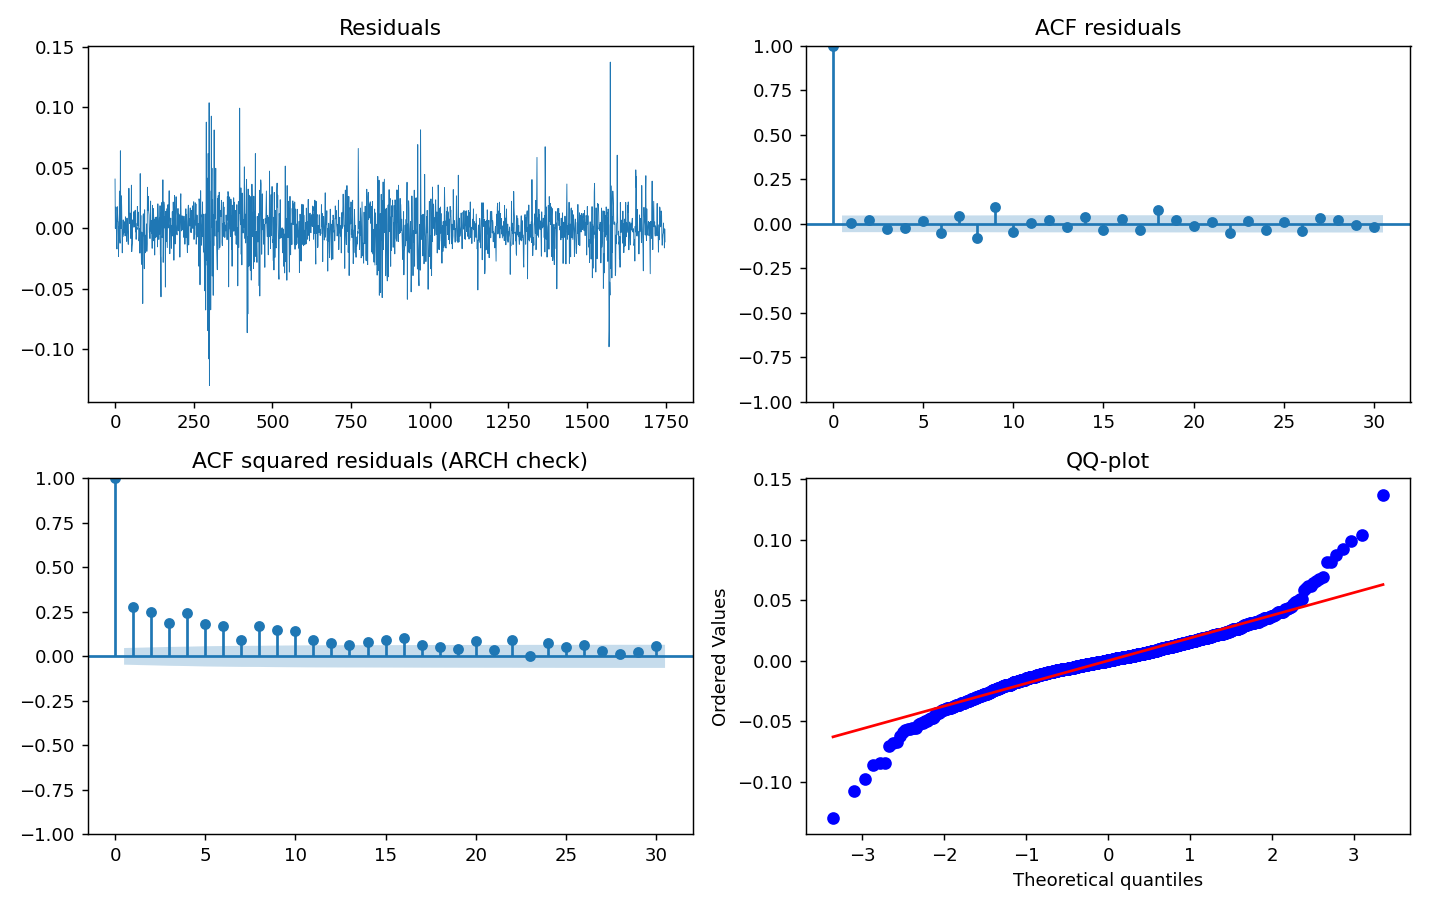

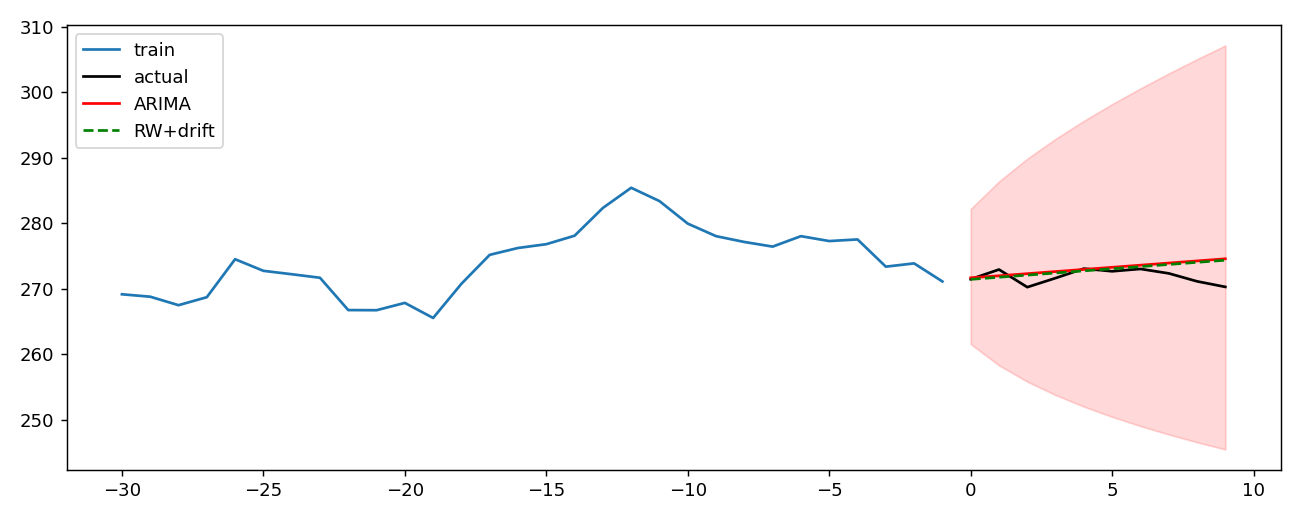

In [6]:
show('04_diag_*.png', '05_arima_forecast.png')

## 3.2 VAR, Granger causality, cointegration
Source: `python/03_var_cointegration.py` (the same file is in the repository; every block is commented with its purpose).

In [7]:
"""
PART 3 (Python) - VAR, Granger causality, cointegration (Engle-Granger + Johansen), VECM
Same study as R/03_var_cointegration.R. Run from the PROJECT ROOT:  python python/03_var_cointegration.py
Needs data/prices.csv (python/01) OR data/prices_R.csv (R/01).  pip install pandas numpy scipy matplotlib statsmodels
NOTE: package conventions differ between R and Python (lag selection in ADF, deterministic terms in Johansen, critical values):
compare CONCLUSIONS between the two languages, not every decimal.
"""
import os, random, warnings
import numpy as np, pandas as pd
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
import statsmodels
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM
from statsmodels.stats.diagnostic import het_arch
import statsmodels.api as sm

warnings.filterwarnings("ignore")
SEED, H = 42, 10; random.seed(SEED); np.random.seed(SEED)            # fixed seed; H = longest horizon of the brief
os.makedirs("data", exist_ok=True); os.makedirs("figures", exist_ok=True)
print("statsmodels", statsmodels.__version__, "| pandas", pd.__version__, "| numpy", np.__version__)

# ---- 1. LOAD + SAME 90/10 SPLIT AS THE R SCRIPTS
if os.path.exists("data/prices.csv"):
    px = pd.read_csv("data/prices.csv", index_col=0, parse_dates=True)[["AdjClose_AAPL", "AdjClose_XLK"]]; px.columns = ["AAPL", "XLK"]
else:
    px = pd.read_csv("data/prices_R.csv", index_col=0, parse_dates=True)[["AAPL", "XLK"]]
lp2 = np.log(px.dropna()).iloc[1:]                                   # drop first obs: same alignment as the return series
n = len(lp2); cut = int(0.9 * n)
Y = pd.DataFrame(lp2.iloc[:cut].values, columns=["AAPL", "XLK"])     # RangeIndex: avoids irregular-date warnings in VAR
Ytest = lp2.iloc[cut:].values
R = Y.diff().dropna()                                                # returns: the stationary representation used for the VAR
print(f"n={n} train={cut} test={n-cut}")

# ---- 2. PRE-CONDITION: both log prices must be I(1)
for v in Y.columns:
    print(v, "| ADF p (level) =", round(adfuller(Y[v], autolag="AIC")[1], 3), "| ADF p (first diff) =", round(adfuller(Y[v].diff().dropna(), autolag="AIC")[1], 4))

# ---- 3. COINTEGRATION, step A: Engle-Granger (residual-based test with the CORRECT critical values: statsmodels.coint)
ols = sm.OLS(Y["AAPL"], sm.add_constant(Y["XLK"])).fit()
print("\nLong-run regression AAPL ~ XLK:", ols.params.round(4).to_dict(), "(t-statistics are NOT valid for non-stationary series)")
eg_stat, eg_p, eg_cv = coint(Y["AAPL"], Y["XLK"], trend="c", autolag="aic")   # H0: NO cointegration
print(f"Engle-Granger: statistic = {eg_stat:.3f}, p = {eg_p:.3f} (R used the Phillips-Ouliaris variant of this test)")
plt.figure(figsize=(10, 4)); plt.plot(ols.resid.values, lw=.7); plt.axhline(0, ls="--", c="k")
plt.title("Long-run spread: AAPL - a - b*XLK (log prices)"); plt.tight_layout(); plt.savefig("figures/08_spread.png", dpi=130); plt.close()

# ---- 4. COINTEGRATION, step B: Johansen trace test
sel = VAR(Y).select_order(10).selected_orders; print("\nLag selection on the level VAR:", sel)
K = max(2, sel["bic"])                                               # K lags in levels <=> K-1 lagged differences in the VECM (BIC, as in R)
def johansen_rank(det, k_diff):
    j = coint_johansen(Y, det_order=det, k_ar_diff=k_diff)           # j.lr1 = trace statistics [r=0, r<=1]; j.cvt columns = 90/95/99%
    rank = (2 if j.lr1[1] > j.cvt[1, 1] else 1) if j.lr1[0] > j.cvt[0, 1] else 0   # sequential decision from r = 0, 5% level
    return j, rank
jo, rank = johansen_rank(0, K - 1)
print(f"Johansen (det_order=0, K={K}): r=0 trace = {jo.lr1[0]:.2f} vs 5% cv {jo.cvt[0,1]:.2f} | r<=1 trace = {jo.lr1[1]:.2f} vs 5% cv {jo.cvt[1,1]:.2f}")
print("Johansen cointegration rank at 5% =", rank)
if rank == 2: print("Rank 2 = full rank = levels stationary: contradicts the I(1) result, check the data / deterministic term.")
print("\nRobustness (deterministic term x lags): r=0 trace statistic vs its own 5% critical value")
for det, name in [(-1, "no-const"), (0, "const"), (1, "trend")]:
    for Kk in (2, 3, 5, 10):
        j, _ = johansen_rank(det, Kk - 1)
        flag = "  [no constant at all: misspecified for log prices, ignore]" if det == -1 else ""
        print(f"  det={name:<8} K={Kk:>2} | stat {j.lr1[0]:6.2f} vs 5% cv {j.cvt[0,1]:6.2f} -> {'REJECT no-cointegration' if j.lr1[0] > j.cvt[0,1] else 'cannot reject'}{flag}")
# Mapping to R (verified on this data): det_order=0 gives EXACTLY the statistics of R's ecdet="none" (unrestricted constant), but statsmodels uses
# different critical-value tables (15.49 vs 17.95). det_order=-1 has no constant at all: inappropriate for log prices (non-zero level), shown for completeness only.
# statsmodels has no restricted-constant option, so R's ecdet="const" has no exact counterpart here. Compare CONCLUSIONS across rows that include a constant.

# ---- 5. VAR ON RETURNS (stationary; correct whether or not the series are cointegrated)
selR = VAR(R).select_order(10).selected_orders; print("\nVAR lag selection on returns:", selR)
pR = max(1, selR["bic"])                                             # BIC order (AIC usually picks more: report both, justify)
var_r = VAR(R).fit(pR, trend="c")
print(pd.concat({"coef": var_r.params, "p-value": var_r.pvalues}, axis=1).round(4))

# Residual diagnostics
wh = var_r.test_whiteness(nlags=10, adjusted=False)                  # portmanteau, H0: no residual autocorrelation
print(f"\nPortmanteau (10 lags): stat = {wh.test_statistic:.2f}, df = {wh.df}, p = {wh.pvalue:.3g}")
nm = var_r.test_normality()                                          # H0: residuals multivariate normal
print(f"Multivariate Jarque-Bera: stat = {nm.test_statistic:.1f}, p = {nm.pvalue:.3g}")
for c in R.columns:                                                  # per-equation ARCH-LM (R reported a multivariate version)
    print(f"ARCH-LM {c} residuals: p(5 lags) = {het_arch(var_r.resid[c], nlags=5)[1]:.3g} | p(10 lags) = {het_arch(var_r.resid[c], nlags=10)[1]:.3g}")
print("Stable VAR:", var_r.is_stable(), "| moduli of companion eigenvalues:", np.round(np.abs(1 / var_r.roots), 3))

# ---- 6. GRANGER CAUSALITY (on the stationary VAR)
for cause, effect in [("AAPL", "XLK"), ("XLK", "AAPL")]:
    g = var_r.test_causality(effect, [cause], kind="f"); i = var_r.test_inst_causality(cause)
    print(f"Granger: {cause} -> {effect}  p = {g.pvalue:.4f} | instantaneous p = {i.pvalue:.4f}")
# Reading: Granger = does the PAST of one help predict the other beyond its own past (predictive, NOT structural causation).
# 'Instantaneous' is expected ~0: same-day returns are 0.83 correlated (comovement, not lead-lag).

# ---- 7. VECM (only if cointegration was found)
vecm_fc = None
if rank >= 1:
    vecm = VECM(Y, k_ar_diff=K - 1, coint_rank=1, deterministic="ci").fit()   # 'ci' = constant inside the long-run relation
    alpha = vecm.alpha[:, 0]
    print("\nCointegrating vector beta:", np.round(vecm.beta[:, 0], 4)); print("Adjustment speeds alpha (AAPL, XLK):", np.round(alpha, 5))
    hl = [np.log(0.5) / np.log(1 + a) if -1 < a < 0 else np.nan for a in alpha]
    print("Half-life (days) per equation (nan = that variable does not correct):", np.round(hl, 1))
    vecm_fc = vecm.predict(steps=H, alpha=0.05)                      # (forecast, lower, upper) in log prices
else:
    print("\nNo cointegration at 5%: VECM not justified. The VAR on returns is the correct multivariate model.")

# ---- 8. FORECAST h=10 AND COMPARISON (same price-scale metrics as R)
fc = var_r.forecast(R.values[-pR:], steps=H)
fc_var = Y["AAPL"].iloc[-1] + np.cumsum(fc[:, 0])                    # cumulate forecast returns back to log price
rw = Y["AAPL"].iloc[-1] + Y["AAPL"].diff().dropna().mean() * np.arange(1, H + 1)
actual = Ytest[:H, 0]
def metrics(y, p):
    y, p = np.exp(y), np.exp(p); e = y - p
    return dict(MSE=np.mean(e**2), RMSE=np.sqrt(np.mean(e**2)), MAE=np.mean(np.abs(e)), MAPE=100 * np.mean(np.abs(e / y)))
tab = {"RW_drift": metrics(actual, rw), "VAR_returns": metrics(actual, fc_var)}
out = pd.DataFrame({"actual_lp": actual, "var_lp": fc_var, "rw_lp": rw})
if vecm_fc is not None:
    tab["VECM"] = metrics(actual, vecm_fc[0][:, 0]); out["vecm_lp"] = vecm_fc[0][:, 0]
print(f"\nForecast accuracy, h={H} (price scale):\n", pd.DataFrame(tab).T.round(4))
print("Caution: 10 points only; the rolling-origin evaluation + Diebold-Mariano (R/06_evaluation.R) is the real comparison.")
out.to_csv("data/forecast_var_py.csv", index=False); pd.DataFrame(tab).T.to_csv("data/metrics_var_py.csv")


statsmodels 0.15.0 | pandas 2.2.3 | numpy 2.1.3
n=1945 train=1750 test=195
AAPL | ADF p (level) = 0.174 | ADF p (first diff) = 0.0
XLK | ADF p (level) = 0.608 | ADF p (first diff) = 0.0

Long-run regression AAPL ~ XLK: {'const': -0.3275, 'XLK': 1.2244} (t-statistics are NOT valid for non-stationary series)
Engle-Granger: statistic = -1.982, p = 0.538 (R used the Phillips-Ouliaris variant of this test)

Lag selection on the level VAR: {'aic': np.int64(10), 'bic': np.int64(2), 'hqic': np.int64(2), 'fpe': np.int64(10)}
Johansen (det_order=0, K=2): r=0 trace = 10.95 vs 5% cv 15.49 | r<=1 trace = 0.70 vs 5% cv 3.84
Johansen cointegration rank at 5% = 0

Robustness (deterministic term x lags): r=0 trace statistic vs its own 5% critical value
  det=no-const K= 2 | stat  16.70 vs 5% cv  12.32 -> REJECT no-cointegration  [no constant at all: misspecified for log prices, ignore]
  det=no-const K= 3 | stat  15.70 vs 5% cv  12.32 -> REJECT no-cointegration  [no constant at all: misspecified for lo

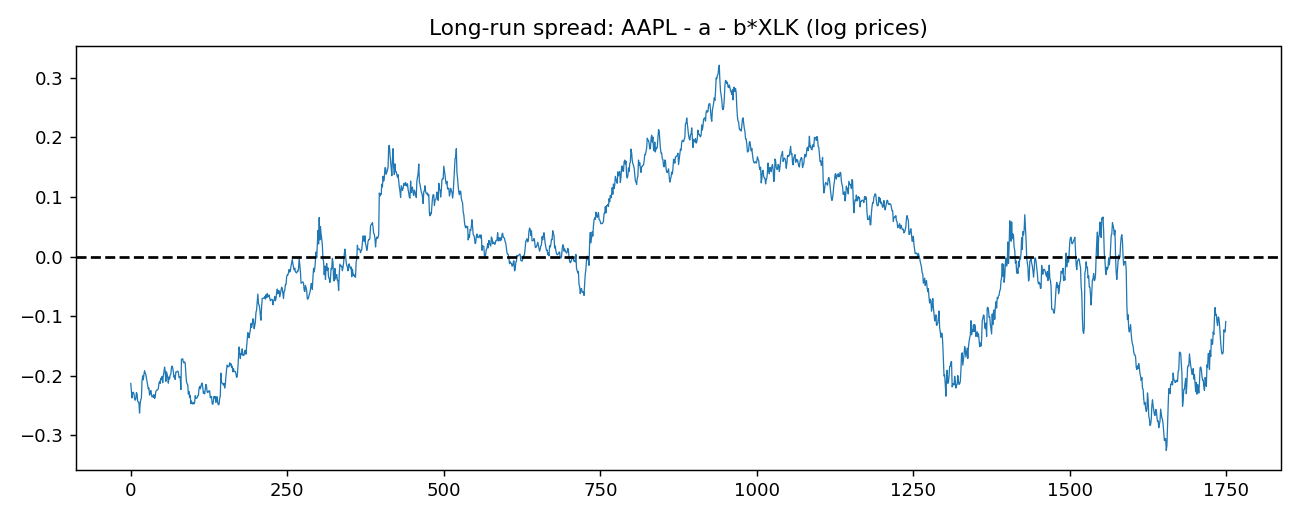

In [8]:
show('08_spread.png')

## 3.3 ARCH / GARCH
Source: `python/04_garch.py` (the same file is in the repository; every block is commented with its purpose).

In [9]:
"""
PART 4 (Python) - ARCH/GARCH: ARCH test, GARCH variants, standardized-residual diagnostics, volatility plot, volatility-aware intervals
Same study as R/04_garch.R (uses the `arch` package). Run from the PROJECT ROOT:  python python/04_garch.py
Needs data/prices.csv (python/01) OR data/prices_R.csv (R/01).  pip install arch pandas numpy scipy matplotlib statsmodels
NOTE: conventions differ from rugarch (e.g. arch's p = ARCH order, q = GARCH order, o = asymmetry); compare CONCLUSIONS, not every decimal.
"""
import os, random, warnings
import numpy as np, pandas as pd
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
import arch as arch_pkg
from arch import arch_model
from scipy import stats
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

warnings.filterwarnings("ignore")
SEED, H = 42, 10; random.seed(SEED); np.random.seed(SEED)
os.makedirs("data", exist_ok=True); os.makedirs("figures", exist_ok=True)
print("arch", arch_pkg.__version__, "| pandas", pd.__version__, "| numpy", np.__version__)

# ---- 1. LOAD + SAME SPLIT (returns in PERCENT: GARCH optimisers are much more stable on a ~1 scale than on ~0.01)
if os.path.exists("data/prices.csv"):
    px = pd.read_csv("data/prices.csv", index_col=0, parse_dates=True)["AdjClose_AAPL"]
else:
    px = pd.read_csv("data/prices_R.csv", index_col=0, parse_dates=True)["AAPL"]
lpf = np.log(px.dropna().values); dates = px.dropna().index[1:]
ret = np.diff(lpf) * 100; n = len(ret); cut = int(0.9 * n)
r_tr, dates_tr = ret[:cut], dates[:cut]
lp_last = lpf[cut]; actual = lpf[cut + 1:cut + 1 + H]                 # same alignment as R/04 and python/02

# ---- 2. ARCH-LM on the residuals of the mean equation ARMA(1,0) (the mean of the ARIMA(1,1,0) chosen in Part 2)
res_mean = ARIMA(r_tr, order=(1, 0, 0)).fit().resid
print("ARCH-LM on ARMA(1,0) residuals, p (5, 10, 20 lags):", [float(f"{het_arch(res_mean, nlags=k)[1]:.3g}") for k in (5, 10, 20)])

# ---- 3. CANDIDATES: GARCH(1,1) is the required baseline; the others are fitted ONLY to see whether diagnostics justify more
cands = {"GARCH(1,1)-norm": dict(p=1, o=0, q=1, dist="normal"),     # normal errors: expected too thin-tailed
         "GARCH(1,1)-std":  dict(p=1, o=0, q=1, dist="t"),          # Student-t: kurtosis was 6.6
         "GARCH(1,1)-sstd": dict(p=1, o=0, q=1, dist="skewt"),      # skewed t: skewness was slightly negative
         "GARCH(2,1)-std":  dict(p=2, o=0, q=1, dist="t"),
         "GARCH(1,2)-std":  dict(p=1, o=0, q=2, dist="t"),
         "GJR(1,1)-std":    dict(p=1, o=1, q=1, dist="t")}           # leverage effect: bad news raises volatility more
fits = {nm: arch_model(r_tr, mean="AR", lags=1, vol="GARCH", **c).fit(disp="off") for nm, c in cands.items()}
ic = pd.DataFrame({nm: dict(loglik=f.loglikelihood, AIC=f.aic, BIC=f.bic, converged=f.convergence_flag == 0) for nm, f in fits.items()}).T
print("\nGARCH comparison (lower AIC/BIC is better):\n", ic.round(2))

# ---- 4. DIAGNOSTICS of the standardized residuals z = e / sigma (must look like white noise AND have constant variance)
def diagnose(res, name, garch_df):
    z = np.asarray(res.std_resid); z = z[~np.isnan(z)]
    lbz = acorr_ljungbox(z, lags=[10, 20], model_df=1)["lb_pvalue"].values             # mean equation (AR(1): 1 parameter)
    lbz2 = acorr_ljungbox(z**2, lags=[10, 20], model_df=garch_df)["lb_pvalue"].values  # variance equation
    print(f"\n=== Standardized residuals: {name} ===")
    print("Ljung-Box on z   p (lag10, lag20):", np.round(lbz, 4)); print("Ljung-Box on z^2 p (lag10, lag20):", np.round(lbz2, 4))
    print("ARCH-LM on z     p (5, 10 lags)   :", [round(float(het_arch(z, nlags=k)[1]), 4) for k in (5, 10)], "(should now be NOT significant)")
    print(f"Jarque-Bera on z p = {stats.jarque_bera(z).pvalue:.3g} (normality is NOT expected: errors are modelled as t; read the QQ-plot against the fitted t)")
    pp = (np.arange(1, len(z) + 1) - 0.5) / len(z)
    if "nu" in res.params.index and "lambda" not in res.params.index:        # standardized Student-t quantiles (unit variance, as in arch)
        nu = res.params["nu"]; q_th = stats.t.ppf(pp, nu) * np.sqrt((nu - 2) / nu); lab = f"t({nu:.1f})"
    else: q_th, lab = stats.norm.ppf(pp), "normal"
    fig, ax = plt.subplots(2, 2, figsize=(11, 7))
    ax[0, 0].plot(z, lw=.5); ax[0, 0].set_title("Standardized residuals")
    plot_acf(z, lags=30, ax=ax[0, 1], title="ACF z"); plot_acf(z**2, lags=30, ax=ax[1, 0], title="ACF z^2 (should be flat)")
    ax[1, 1].plot(q_th, np.sort(z), ".", ms=3); lim = [q_th.min(), q_th.max()]; ax[1, 1].plot(lim, lim, "r"); ax[1, 1].set_title(f"QQ vs fitted {lab}")
    plt.tight_layout(); plt.savefig("figures/09_garch_diag_" + "".join(ch for ch in name if ch.isalnum()) + ".png", dpi=130); plt.close()
MAIN = "GARCH(1,1)-std"; fit_main = fits[MAIN]
diagnose(fit_main, MAIN, garch_df=2)
best = ic["BIC"].astype(float).idxmin()
if best != MAIN: diagnose(fits[best], best, garch_df=cands[best]["p"] + cands[best]["q"] + cands[best]["o"])
print("\nBest by BIC:", best)
print(fit_main.summary())

# ---- 5. PERSISTENCE AND UNCONDITIONAL VOLATILITY
P = fit_main.params; pers = P["alpha[1]"] + P["beta[1]"]
print(f"\nPersistence alpha+beta = {pers:.4f} | half-life of a volatility shock = {np.log(0.5)/np.log(pers):.1f} days"
      f" | long-run vol = {np.sqrt(P['omega']/(1-pers))*np.sqrt(252):.1f}% annualised")
if "gamma[1]" in fits["GJR(1,1)-std"].params.index:
    g = fits["GJR(1,1)-std"]; print(f"GJR leverage coefficient gamma = {g.params['gamma[1]']:.4f} (p = {g.pvalues['gamma[1]']:.4f}); a positive, significant gamma would mean bad news raises volatility more")

# ---- 6. CONDITIONAL VOLATILITY OVER TIME (annualised), linked to events -> label the red lines yourself after checking the news
vol = np.asarray(fit_main.conditional_volatility) * np.sqrt(252); d_vol = dates_tr[-len(vol):]   # first value is NaN with an AR(1) mean
plt.figure(figsize=(11, 4)); plt.plot(d_vol, vol, lw=.8)
for e in ["2020-03-16", "2022-11-10", "2025-04-09"]:                    # extreme-return dates found in Part 1
    plt.axvline(pd.Timestamp(e), ls="--", c="r", lw=.8); plt.text(pd.Timestamp(e), np.nanmax(vol) * 1.01, e, color="r", fontsize=7, ha="center")
plt.ylabel("% annualised"); plt.title("AAPL conditional volatility, GARCH(1,1)-t"); plt.tight_layout(); plt.savefig("figures/10_cond_vol.png", dpi=130); plt.close()
print(f"Peak conditional volatility: {np.nanmax(vol):.1f}% on {d_vol[np.nanargmax(vol)].date()}")
pd.DataFrame({"date": d_vol, "sigma_ann": vol}).to_csv("data/garch_condvol_py.csv", index=False)

# ---- 7. FORECAST h=10: the mean is almost the ARIMA one; the GARCH contribution is the volatility-aware INTERVAL
f = fit_main.forecast(horizon=H, reindex=False)
mu_r = f.mean.values[-1] / 100; sg = np.sqrt(f.variance.values[-1]) / 100
lp_hat = lp_last + np.cumsum(mu_r)
half = 1.96 * np.sqrt(np.cumsum(sg**2))                                # sum of daily variances; ~normal for multi-day sums
nu = P["nu"]; half[0] = stats.t.ppf(0.975, nu) * np.sqrt((nu - 2) / nu) * sg[0]   # day 1: exact standardized-t quantile
lo, hi = lp_hat - half, lp_hat + half
print("\nForecast sigma (annualised %) day 1 -> day 10:", round(sg[0] * np.sqrt(252) * 100, 1), "->", round(sg[-1] * np.sqrt(252) * 100, 1))
def metrics(y, p):
    y, p = np.exp(y), np.exp(p); e = y - p
    return dict(MSE=np.mean(e**2), RMSE=np.sqrt(np.mean(e**2)), MAE=np.mean(np.abs(e)), MAPE=100 * np.mean(np.abs(e / y)))
rw = lp_last + (r_tr.mean() / 100) * np.arange(1, H + 1)
tab = {"RW_drift": metrics(actual, rw), "ARMA_GARCH": metrics(actual, lp_hat)}
cover = {"GARCH": np.mean((actual >= lo) & (actual <= hi)), "GARCH_width": np.mean(np.exp(hi) - np.exp(lo))}
if os.path.exists("data/forecast_arima.csv"):                          # written by python/02_arima.py
    a2 = pd.read_csv("data/forecast_arima.csv"); tab["ARIMA"] = metrics(actual, a2["arima_lp"].values)
    cover["ARIMA"] = np.mean((actual >= a2["lo"].values) & (actual <= a2["hi"].values)); cover["ARIMA_width"] = np.mean(np.exp(a2["hi"].values) - np.exp(a2["lo"].values))
print(f"\nForecast accuracy, h={H} (price scale):\n", pd.DataFrame(tab).T.round(4))
print("Interval coverage / width (10 points, not informative on its own):", {k: round(float(v), 3) for k, v in cover.items()})
print("Interpretation: ARIMA assumes the AVERAGE past volatility forever; GARCH uses the CURRENT volatility state.")
pd.DataFrame({"actual_lp": actual, "garch_lp": lp_hat, "lo": lo, "hi": hi}).to_csv("data/forecast_garch_py.csv", index=False)
pd.DataFrame(tab).T.to_csv("data/metrics_garch_py.csv")

# ---- 8. SENSITIVITY: does the AR(1) term / the very first observation (2019-01-03, a -10.5% day) matter?
rows = {}
for label, y, mean in [("AR(1), all obs", r_tr, "AR"), ("constant mean, all obs", r_tr, "Constant"), ("constant mean, drop first", r_tr[1:], "Constant")]:
    kw = dict(lags=1) if mean == "AR" else {}
    r_ = arch_model(y, mean=mean, vol="GARCH", p=1, q=1, dist="t", **kw).fit(disp="off"); rows[label] = r_.params.rename({"mu": "Const"})
print("\nSensitivity of the GARCH(1,1)-t parameters:\n", pd.DataFrame(rows).T.round(4).to_string())


arch 8.0.0 | pandas 2.2.3 | numpy 2.1.3
ARCH-LM on ARMA(1,0) residuals, p (5, 10, 20 lags): [5.74e-51, 1.98e-51, 1.74e-47]

GARCH comparison (lower AIC/BIC is better):
                       loglik          AIC          BIC converged
GARCH(1,1)-norm -3450.062477  6910.124954  6937.458952      True
GARCH(1,1)-std  -3383.835043  6779.670086  6812.470883      True
GARCH(1,1)-sstd -3383.634132  6781.268264  6819.535861      True
GARCH(2,1)-std  -3383.835043  6781.670086  6819.937682      True
GARCH(1,2)-std  -3383.485719  6780.971438  6819.239034      True
GJR(1,1)-std    -3373.635993  6761.271986  6799.539582      True

=== Standardized residuals: GARCH(1,1)-std ===
Ljung-Box on z   p (lag10, lag20): [0.6471 0.6387]
Ljung-Box on z^2 p (lag10, lag20): [0.3672 0.7535]
ARCH-LM on z     p (5, 10 lags)   : [0.4199, 0.5319] (should now be NOT significant)
Jarque-Bera on z p = 1.26e-101 (normality is NOT expected: errors are modelled as t; read the QQ-plot against the fitted t)

=== Standardized

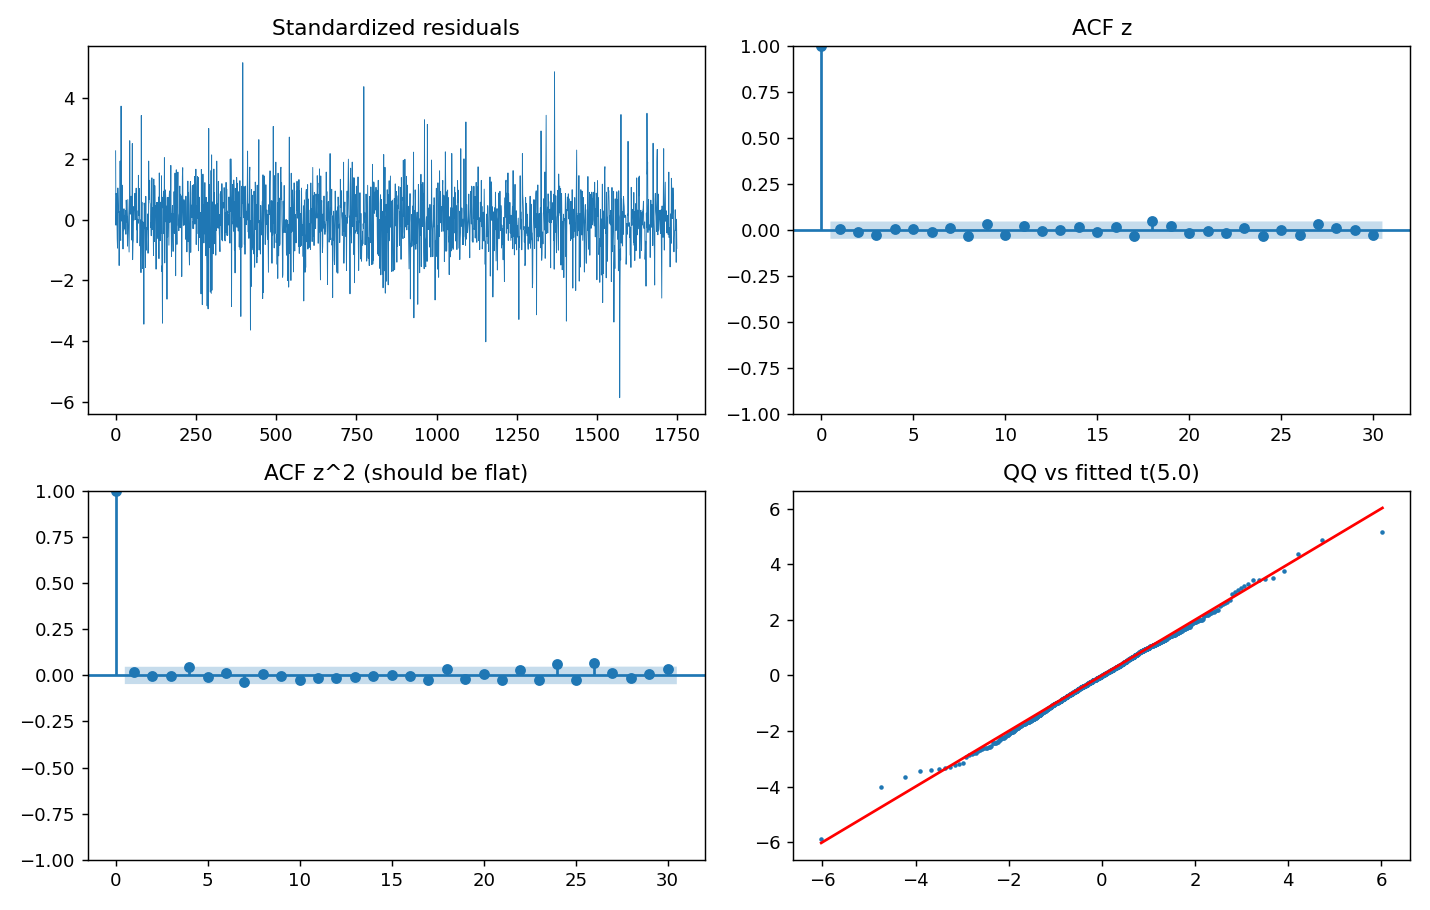

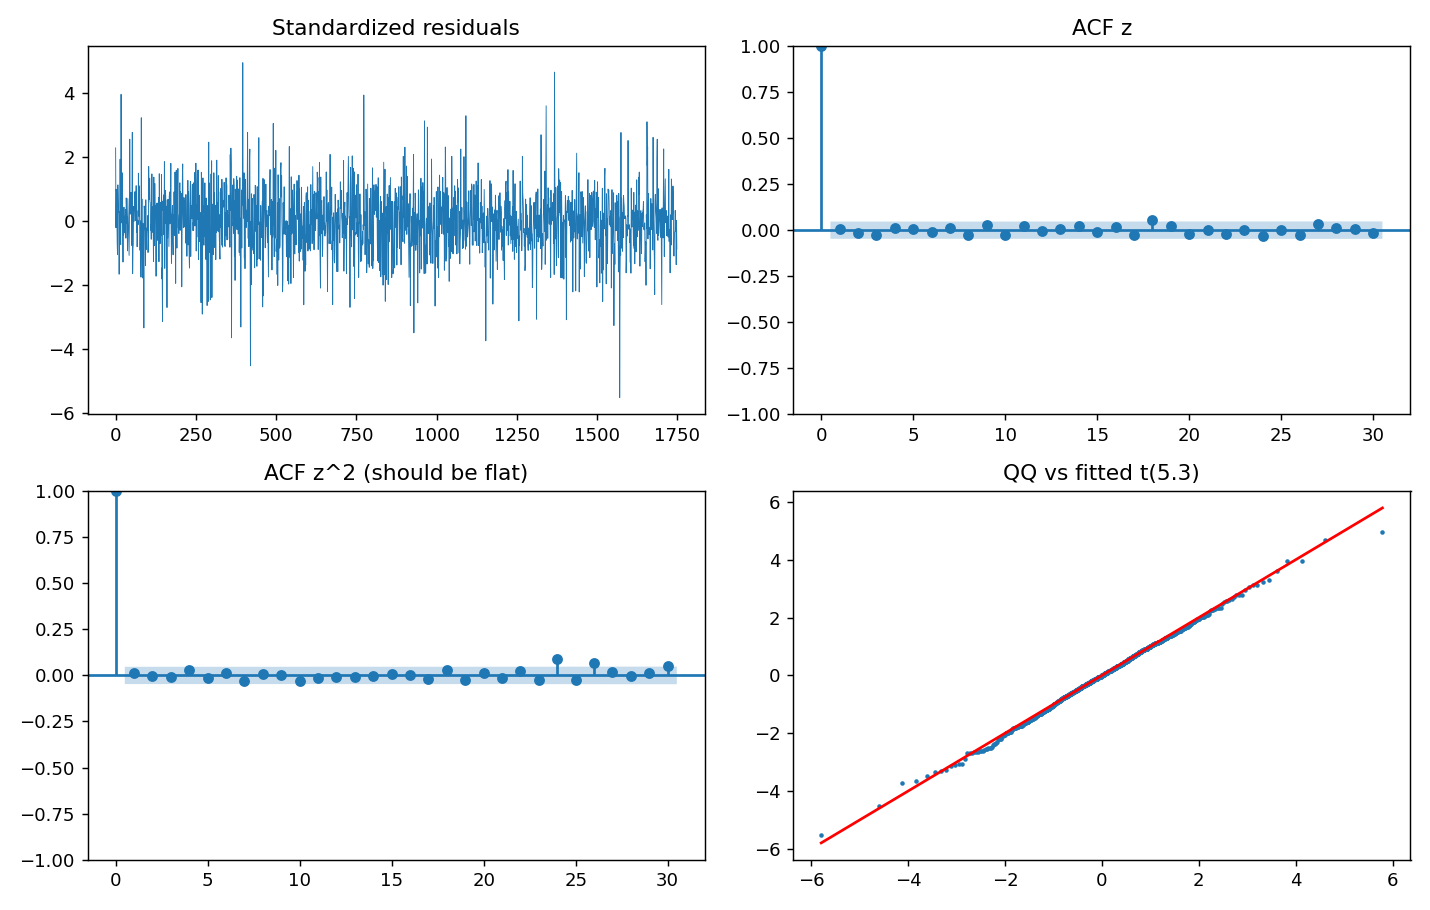

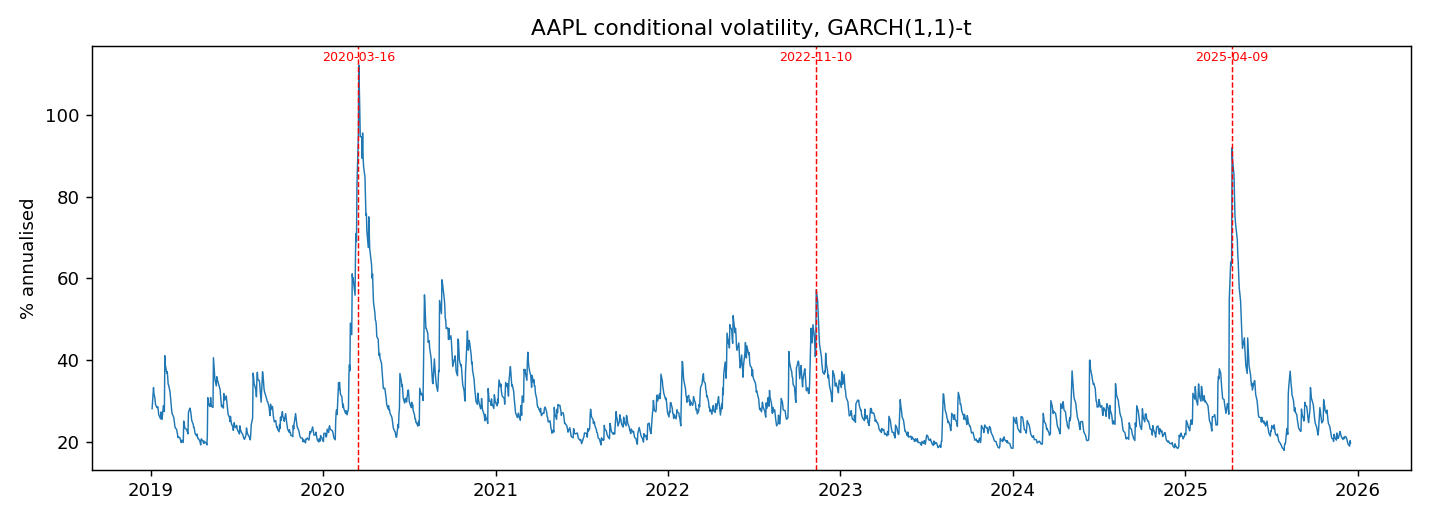

In [10]:
show('09_garch_diag_*.png', '10_cond_vol.png')

## 4. LSTM and GRU with walk-forward validation (advanced core, Python only)
Source: `python/05_lstm_gru.py` (the same file is in the repository; every block is commented with its purpose).

In [11]:
"""
PART 5 (Python) - LSTM and GRU with walk-forward validation, evaluated on rolling test forecasts
Run from the PROJECT ROOT:  python python/05_lstm_gru.py
Quick smoke test (3 min):   QUICK=1 python python/05_lstm_gru.py      (Git Bash)   |   set QUICK=1  then run (cmd)
Needs: data/prices.csv (python/01) OR data/prices_R.csv (R/01). pip install tensorflow pandas numpy matplotlib statsmodels
"""
import os, random, time
os.environ.setdefault("TF_ENABLE_ONEDNN_OPTS", "0")   # silences the oneDNN notice, makes CPU numerics more reproducible
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")    # hides TensorFlow info messages
import numpy as np, pandas as pd
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers as L
from statsmodels.stats.diagnostic import acorr_ljungbox

# ------------------------------------------------------------------ SETTINGS (each one justified)
SEED, H = 42, 10                                       # H=10: longest horizon in the brief (5..10)
QUICK = os.environ.get("QUICK", "0") == "1"
K_FOLDS = 3 if QUICK else 4                            # walk-forward folds inside the TRAIN period
WINDOW_GRID = [20] if QUICK else [20, 60]              # 20 d ~ 1 trading month; 60 d ~ 1 quarter. The GARCH half-life of a volatility shock was 21 d, so memory beyond ~60 d is unlikely to matter
UNITS_GRID = [16] if QUICK else [16, 32]               # small nets: only ~1,700 training windows -> large nets overfit
N_LAYERS = 1                                           # 1 recurrent layer: depth buys nothing at this sample size (can be changed and re-run as an ablation)
DROPOUT = 0.2                                          # regularisation against overfitting a very noisy target
MAX_EPOCHS, BATCH, PATIENCE = (30 if QUICK else 80), 32, 8   # early stopping decides the real number of epochs
os.makedirs("data", exist_ok=True); os.makedirs("figures", exist_ok=True)
print("tensorflow", tf.__version__, "| numpy", np.__version__, "| pandas", pd.__version__, "| QUICK =", QUICK)

def seed_all():
    random.seed(SEED); np.random.seed(SEED); keras.utils.set_random_seed(SEED)

# ------------------------------------------------------------------ 1. DATA (same alignment and 90/10 split as the R scripts)
def load_prices():
    if os.path.exists("data/prices.csv"):
        d = pd.read_csv("data/prices.csv", index_col=0, parse_dates=True)[["AdjClose_AAPL", "AdjClose_XLK"]]
        d.columns = ["AAPL", "XLK"]
    else:
        d = pd.read_csv("data/prices_R.csv", index_col=0, parse_dates=True)[["AAPL", "XLK"]]
    return d.dropna()
px = load_prices()
lpf = np.log(px.values)                                # log prices, n+1 rows
R = np.diff(lpf, axis=0); dates = px.index[1:]         # log returns, n rows (return i = change during day i)
n = len(R); cut = int(0.9 * n)                         # train = returns 0..cut-1, test = cut..n-1
r_a = R[:, 0]
# Inputs: AAPL return, XLK return (the multivariate part of the project), 10-day rolling volatility of AAPL (uses only past data)
vol10 = pd.Series(r_a).rolling(10, min_periods=1).std().fillna(0).values
F = np.column_stack([R[:, 0], R[:, 1], vol10])
print(f"n={n} train={cut} test={n-cut} | features: AAPL return, XLK return, 10-d volatility")
# TARGET = the next H daily returns (not prices): prices are non-stationary and a network cannot extrapolate beyond the
# price range it saw in training; returns are stationary. Price forecasts are rebuilt by cumulating predicted returns.

def make_samples(origins, W):
    """origin t = last observed day: input = features of days t-W+1..t, target = returns of days t+1..t+H."""
    X = np.stack([F[t - W + 1:t + 1] for t in origins]); Y = np.stack([r_a[t + 1:t + 1 + H] for t in origins])
    return X, Y

class Scaler:                                          # always fitted on the TRAINING part only (no look-ahead)
    def __init__(s, F_tr, r_tr): s.mu, s.sd, s.ysd = F_tr.mean(0), F_tr.std(0) + 1e-8, r_tr.std() + 1e-12
    def x(s, X): return (X - s.mu) / s.sd
    def y(s, Y): return Y / s.ysd

# ------------------------------------------------------------------ 2. MODEL
def build(arch, W, units):
    cell = L.LSTM if arch == "LSTM" else L.GRU         # the ONLY difference between the two models
    m = keras.Sequential([keras.Input((W, F.shape[1]))])
    for i in range(N_LAYERS):
        m.add(cell(units, dropout=DROPOUT, return_sequences=(i < N_LAYERS - 1)))
    m.add(L.Dropout(DROPOUT)); m.add(L.Dense(H))       # one output per forecast horizon (direct multi-horizon forecast)
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
    return m

def fit_rnn(arch, W, units, Xs, Ys):
    seed_all(); keras.backend.clear_session()
    m = build(arch, W, units)
    n_val = int(0.15 * len(Xs)); tr_end = len(Xs) - n_val - H   # validation = LAST 15% in time, with a gap of H so target windows do not overlap
    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)
    hist = m.fit(Xs[:tr_end], Ys[:tr_end], validation_data=(Xs[-n_val:], Ys[-n_val:]),
                 epochs=MAX_EPOCHS, batch_size=BATCH, callbacks=[es], verbose=0)   # shuffling windows INSIDE the train block is not look-ahead
    return m, hist.history

# ------------------------------------------------------------------ 3. WALK-FORWARD (expanding-window) CROSS-VALIDATION inside the training period
# Never k-fold: each fold trains on the past only and is scored on the block right after it.
def cv_config(arch, W, units):
    n0 = int(0.5 * cut); B = (cut - n0) // K_FOLDS; out = []
    for k in range(K_FOLDS):
        fs, fe = n0 + k * B, n0 + (k + 1) * B                 # fold k: train on days < fs, evaluate on days fs..fe-1
        sc = Scaler(F[:fs], r_a[:fs])
        Xtr, Ytr = make_samples(np.arange(W - 1, fs - H), W)  # targets end at fs-1: nothing from the evaluation block
        Xev, Yev = make_samples(np.arange(fs - 1, fe - H), W) # first target = day fs
        m, _ = fit_rnn(arch, W, units, sc.x(Xtr), sc.y(Ytr))
        P = m.predict(sc.x(Xev), verbose=0); Ye = sc.y(Yev)
        mse = np.mean((P - Ye) ** 2)
        base = np.mean((sc.y(Ytr).mean(0) - Ye) ** 2)         # benchmark: always predict the average training return
        out.append(dict(arch=arch, W=W, units=units, fold=k, mse=mse, base_mse=base, ratio=mse / base))
    return out

t0 = time.time(); rows = []
for arch in ["LSTM", "GRU"]:
    for W in WINDOW_GRID:
        for u in UNITS_GRID:
            rows += cv_config(arch, W, u); print(f"  CV done: {arch} W={W} units={u}  ({time.time()-t0:.0f}s)")
cv = pd.DataFrame(rows); cv.to_csv("data/rnn_cv_folds_py.csv", index=False)
summ = cv.groupby(["arch", "W", "units"]).agg(mse=("mse", "mean"), ratio=("ratio", "mean"), ratio_sd=("ratio", "std")).reset_index()
print("\nWalk-forward CV (scaled MSE; ratio = model MSE / 'predict the average return' MSE; ratio < 1 means the net beats the benchmark):")
print(summ.round(4).to_string(index=False)); summ.to_csv("data/rnn_cv_summary_py.csv", index=False)

# ------------------------------------------------------------------ 4. FINAL MODELS: best config per architecture, trained on the whole training period
sc = Scaler(F[:cut], r_a[:cut]); test_orig = np.arange(cut - 1, n - H)       # rolling forecast origins across the test set
hists, preds = {}, {}
for arch in ["LSTM", "GRU"]:
    b = summ[summ.arch == arch].sort_values("mse").iloc[0]; W, u = int(b.W), int(b.units)
    print(f"\n{arch}: chosen window={W}, units={u}")
    Xtr, Ytr = make_samples(np.arange(W - 1, cut - H), W)
    m, hists[arch] = fit_rnn(arch, W, u, sc.x(Xtr), sc.y(Ytr))
    print(f"  parameters: {m.count_params()} | epochs run: {len(hists[arch]['loss'])} | best val loss: {min(hists[arch]['val_loss']):.4f}")
    Xte, _ = make_samples(test_orig, W)            # the model is NOT refitted on test data; its inputs are the actual past returns at each origin
    preds[arch] = m.predict(sc.x(Xte), verbose=0) * sc.ysd   # back to raw log returns

# ------------------------------------------------------------------ 5. LOSS CURVES (training procedure documentation)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, arch in zip(ax, hists):
    a.plot(hists[arch]["loss"], label="train"); a.plot(hists[arch]["val_loss"], label="validation")
    a.set_title(f"{arch}: loss (MSE, scaled)"); a.set_xlabel("epoch"); a.legend()
plt.tight_layout(); plt.savefig("figures/06_rnn_loss.png", dpi=130); plt.close()

# ------------------------------------------------------------------ 6. ROLLING TEST FORECASTS -> price scale, same metrics as the R scripts
lp_t = lpf[test_orig + 1, 0]                                   # log price at each origin
steps = np.arange(1, H + 1)
actual = np.stack([lpf[test_orig + 1 + h, 0] for h in steps], axis=1)
mu = r_a[:cut].mean()
fc = {"lstm_lp": lp_t[:, None] + np.cumsum(preds["LSTM"], axis=1),
      "gru_lp": lp_t[:, None] + np.cumsum(preds["GRU"], axis=1),
      "rw0_lp": np.repeat(lp_t[:, None], H, axis=1),           # random walk without drift
      "rwdrift_lp": lp_t[:, None] + mu * steps}                # random walk with the TRAIN drift
def metrics(y_lp, p_lp):
    y, p = np.exp(y_lp), np.exp(p_lp); e = y - p
    return dict(MSE=np.mean(e**2), RMSE=np.sqrt(np.mean(e**2)), MAE=np.mean(np.abs(e)), MAPE=100 * np.mean(np.abs(e / y)))
tab = pd.DataFrame({(name.replace("_lp", ""), f"h={h}"): metrics(actual[:, h-1], fc[name][:, h-1])
                    for name in fc for h in (1, 5, 10)}).T
print(f"\nRolling forecasts over {len(test_orig)} test origins (price scale):\n", tab.round(4)); tab.to_csv("data/metrics_rnn_py.csv")

# One long CSV, one row per (origin, horizon): the R evaluation script merges ARIMA / GARCH forecasts on the same origins
long = pd.DataFrame({"origin": np.repeat(np.arange(len(test_orig)), H), "origin_date": np.repeat(dates[test_orig].astype(str), H),
                     "h": np.tile(steps, len(test_orig)), "actual_lp": actual.ravel(), **{k: v.ravel() for k, v in fc.items()}})
long.to_csv("data/forecast_rnn_py.csv", index=False)

# ------------------------------------------------------------------ 7. DOES THE NETWORK ACTUALLY HAVE SKILL? (1-day-ahead returns)
a1 = r_a[test_orig + 1]
print("\n1-day-ahead return check on the test set:")
for arch in ["LSTM", "GRU"]:
    p1 = preds[arch][:, 0]; err = a1 - p1
    print(f"  {arch}: corr(pred, actual) = {np.corrcoef(p1, a1)[0,1]:.3f} | direction hit-rate = {np.mean(np.sign(p1) == np.sign(a1)):.1%}"
          f" | Ljung-Box p on errors (lag 10) = {acorr_ljungbox(err, lags=[10])['lb_pvalue'].iloc[0]:.3f}")
print(f"  share of up-days in the test set = {np.mean(a1 > 0):.1%} (a hit-rate near this value means no directional skill)")
fig, ax = plt.subplots(figsize=(10, 3.5)); ax.plot(a1, lw=.6, label="actual"); ax.plot(preds["LSTM"][:, 0], label="LSTM"); ax.plot(preds["GRU"][:, 0], label="GRU")
ax.set_title("1-day-ahead return forecasts, test set"); ax.legend(); plt.tight_layout(); plt.savefig("figures/07_rnn_h1.png", dpi=130); plt.close()
print(f"\nTotal time: {time.time()-t0:.0f}s. Saved data/forecast_rnn_py.csv, data/metrics_rnn_py.csv, figures/06_rnn_loss.png, 07_rnn_h1.png")


tensorflow 2.21.0 | numpy 2.1.3 | pandas 2.2.3 | QUICK = False
n=1945 train=1750 test=195 | features: AAPL return, XLK return, 10-d volatility

  CV done: LSTM W=20 units=16  (48s)
  CV done: LSTM W=20 units=32  (88s)
  CV done: LSTM W=60 units=16  (143s)
  CV done: LSTM W=60 units=32  (205s)
  CV done: GRU W=20 units=16  (267s)
  CV done: GRU W=20 units=32  (314s)
  CV done: GRU W=60 units=16  (386s)
  CV done: GRU W=60 units=32  (467s)

Walk-forward CV (scaled MSE; ratio = model MSE / 'predict the average return' MSE; ratio < 1 means the net beats the benchmark):
arch  W  units    mse  ratio  ratio_sd
 GRU 20     16 0.7205 1.0101    0.0071
 GRU 20     32 0.7199 1.0116    0.0090
 GRU 60     16 0.7170 1.0054    0.0041
 GRU 60     32 0.7184 1.0089    0.0067
LSTM 20     16 0.7194 1.0108    0.0079
LSTM 20     32 0.7182 1.0091    0.0075
LSTM 60     16 0.7186 1.0084    0.0037
LSTM 60     32 0.7177 1.0079    0.0053

LSTM: chosen window=60, units=32
  parameters: 4938 | epochs run: 10 | best 

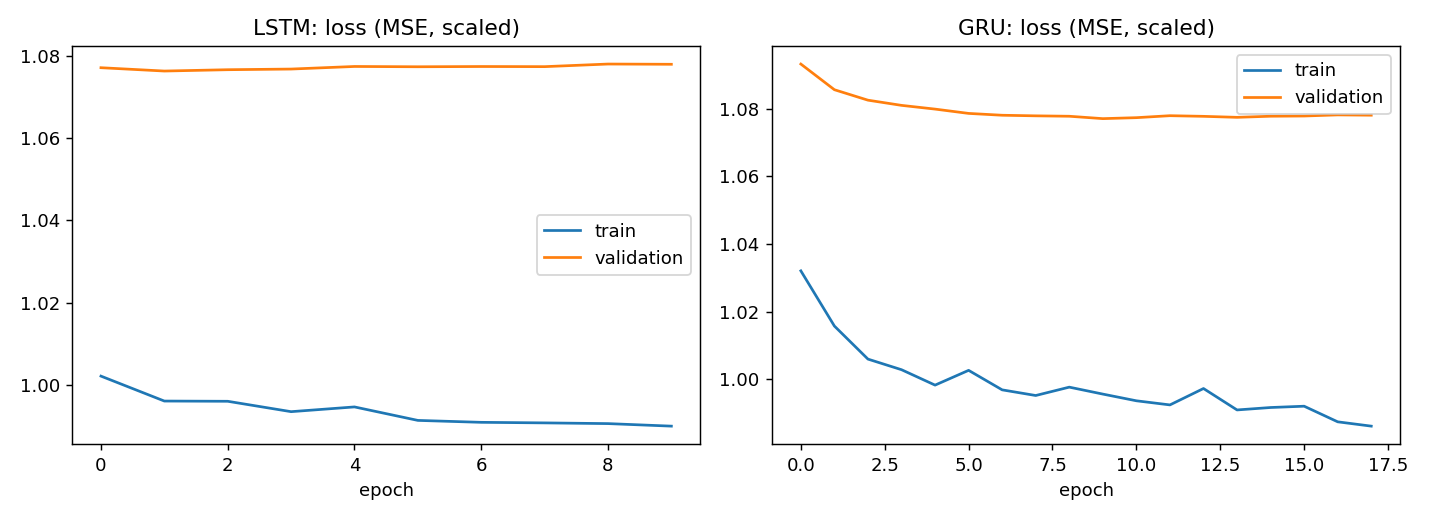

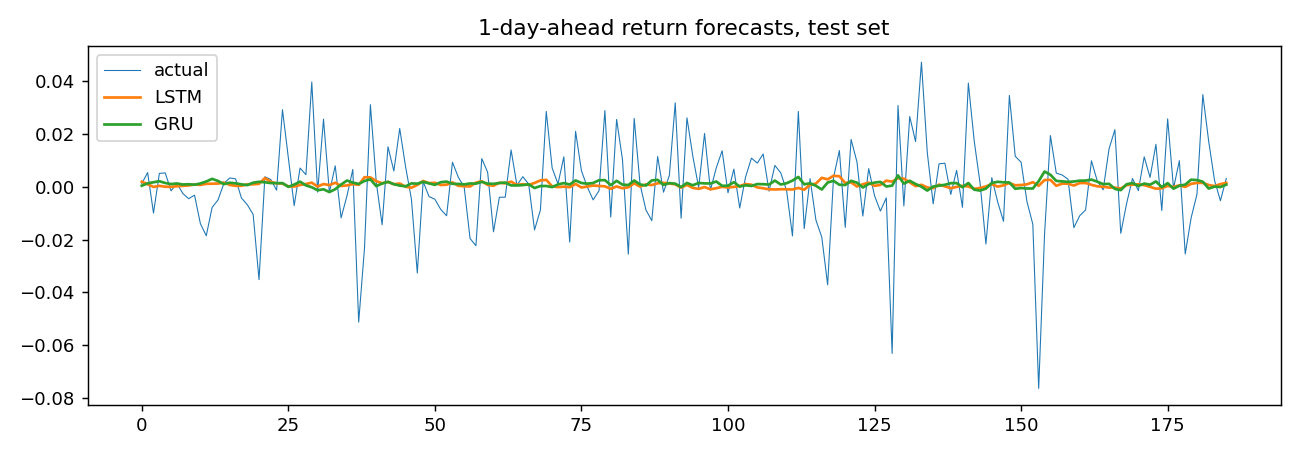

In [12]:
show('06_rnn_loss.png', '07_rnn_h1.png')

## Package versions
The versions used are printed at the top of each section above.

In [13]:
import importlib.metadata as m
for p in ['numpy','pandas','scipy','statsmodels','arch','pmdarima','tensorflow','matplotlib','yfinance']:
    try: print(p, m.version(p))
    except Exception: print(p, 'not installed')

numpy 2.1.3
pandas 2.2.3
scipy 1.15.3
statsmodels 0.15.0
arch 8.0.0
pmdarima 2.1.1
tensorflow 2.21.0
matplotlib 3.10.0
yfinance 1.7.0
